# Model evaluation: generate data and exploratory figures
Generates plot-level and grid-level arrays for both paper figures, saves them to disk, and makes exploratory spatial hexbin figures.

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from conus_biomass.process_inputs import bin_nfi_plots
from conus_biomass.train_models import (
    train_all_models,
    train_model_delta_burned,
    train_model_delta_unburned,
    train_model_init_biomass,
    train_models_utils,
)

In [2]:
OUT_DIR = "../figure_data/figure_S_Evaluation/"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
dir_models = "/dfs10/jranders_lab1/users/czarakas/uncertain_land_sink_data/processed_data/models/"

fia_data = train_all_models.load_data()
fia_data = fia_data.where(
    fia_data["STATECD"].isin([4, 6, 8, 16, 30, 32, 35, 41, 49, 53, 56]).load(), drop=True
)

## Collect plot-level predictions across model folds

In [4]:
y_test_init_actual_list = []
y_test_burned_actual_list = []
y_test_undisturbed_actual_list = []
y_test_init_pred_list = []
y_test_burned_pred_list = []
y_test_undisturbed_pred_list = []

lat_init_list = []
lat_burned_list = []
lat_undisturbed_list = []
lon_init_list = []
lon_burned_list = []
lon_undisturbed_list = []

for model_suffix in ["_0000", "_0001", "_0002"]:

    test_train_split = xr.open_dataset(dir_models + "train_plotids" + model_suffix + ".nc")
    model_initial_biomass = joblib.load(
        train_model_init_biomass.FPATH_MODEL + model_suffix + ".pkl"
    )
    model_burned = joblib.load(train_model_delta_burned.FPATH_MODEL + model_suffix + ".pkl")
    model_undisturbed = joblib.load(train_model_delta_unburned.FPATH_MODEL + model_suffix + ".pkl")

    fia_data_test = fia_data.where(~test_train_split["is_train"], drop=True)
    fia_data_test_burned, fia_data_test_undisturbed = train_all_models.split_subcomponents(
        fia_data_test
    )

    [X_test_init, y_test_init] = train_models_utils.get_X_y(
        fia_data=fia_data_test,
        fia_variable_predictors=train_model_init_biomass.FIA_VARIABLE_PREDICTORS,
        predictors_meas1=train_model_init_biomass.PREDICTOR_VARIABLES_MEAS1,
        predictors_meas2=train_model_init_biomass.PREDICTOR_VARIABLES_MEAS2,
        output_variable=train_model_init_biomass.OUTPUT_VARIABLE,
    )
    [X_test_burned, y_test_burned] = train_models_utils.get_X_y(
        fia_data=fia_data_test_burned,
        fia_variable_predictors=train_model_delta_burned.FIA_VARIABLE_PREDICTORS,
        predictors_meas1=train_model_delta_burned.PREDICTOR_VARIABLES_MEAS1,
        predictors_meas2=train_model_delta_burned.PREDICTOR_VARIABLES_MEAS2,
        output_variable=train_model_delta_burned.OUTPUT_VARIABLE,
    )
    [X_test_undisturbed, y_test_undisturbed] = train_models_utils.get_X_y(
        fia_data=fia_data_test_undisturbed,
        fia_variable_predictors=train_model_delta_unburned.FIA_VARIABLE_PREDICTORS,
        predictors_meas1=train_model_delta_unburned.PREDICTOR_VARIABLES_MEAS1,
        predictors_meas2=train_model_delta_unburned.PREDICTOR_VARIABLES_MEAS2,
        output_variable=train_model_delta_unburned.OUTPUT_VARIABLE,
    )

    y_pred_init_test = model_initial_biomass.predict(X_test_init)
    y_pred_burned_test = model_burned.predict(X_test_burned)
    y_pred_undisturbed_test = model_undisturbed.predict(X_test_undisturbed)

    y_test_init_actual_list.append(y_test_init.values)
    y_test_burned_actual_list.append(y_test_burned.values)
    y_test_undisturbed_actual_list.append(y_test_undisturbed.values)
    y_test_init_pred_list.append(y_pred_init_test)
    y_test_burned_pred_list.append(y_pred_burned_test)
    y_test_undisturbed_pred_list.append(y_pred_undisturbed_test)

    # Re-fetch with lat/lon for spatial binning
    [X_test_burned, y_test_burned] = train_models_utils.get_X_y(
        fia_data=fia_data_test_burned,
        fia_variable_predictors=train_model_delta_burned.FIA_VARIABLE_PREDICTORS + ["lat", "lon"],
        predictors_meas1=train_model_delta_burned.PREDICTOR_VARIABLES_MEAS1,
        predictors_meas2=train_model_delta_burned.PREDICTOR_VARIABLES_MEAS2,
        output_variable=train_model_delta_burned.OUTPUT_VARIABLE,
    )
    [X_test_undisturbed, y_test_undisturbed] = train_models_utils.get_X_y(
        fia_data=fia_data_test_undisturbed,
        fia_variable_predictors=train_model_delta_unburned.FIA_VARIABLE_PREDICTORS + ["lat", "lon"],
        predictors_meas1=train_model_delta_unburned.PREDICTOR_VARIABLES_MEAS1,
        predictors_meas2=train_model_delta_unburned.PREDICTOR_VARIABLES_MEAS2,
        output_variable=train_model_delta_unburned.OUTPUT_VARIABLE,
    )

    lat_init_list.append(X_test_init["lat"].values)
    lat_burned_list.append(X_test_burned["lat"].values)
    lat_undisturbed_list.append(X_test_undisturbed["lat"].values)
    lon_init_list.append(X_test_init["lon"].values)
    lon_burned_list.append(X_test_burned["lon"].values)
    lon_undisturbed_list.append(X_test_undisturbed["lon"].values)

y_test_init = np.concatenate(y_test_init_actual_list)
y_test_burned = np.concatenate(y_test_burned_actual_list)
y_test_undisturbed = np.concatenate(y_test_undisturbed_actual_list)
y_pred_init_test = np.concatenate(y_test_init_pred_list)
y_pred_burned_test = np.concatenate(y_test_burned_pred_list)
y_pred_undisturbed_test = np.concatenate(y_test_undisturbed_pred_list)

lat_init = np.concatenate(lat_init_list)
lat_burned = np.concatenate(lat_burned_list)
lat_undisturbed = np.concatenate(lat_undisturbed_list)
lon_init = np.concatenate(lon_init_list)
lon_burned = np.concatenate(lon_burned_list)
lon_undisturbed = np.concatenate(lon_undisturbed_list)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 wh

## Save plot-level arrays

In [6]:
np.save(OUT_DIR + "y_test_init.npy", y_test_init)
np.save(OUT_DIR + "y_test_burned.npy", y_test_burned)
np.save(OUT_DIR + "y_test_undisturbed.npy", y_test_undisturbed)
np.save(OUT_DIR + "y_pred_init_test.npy", y_pred_init_test)
np.save(OUT_DIR + "y_pred_burned_test.npy", y_pred_burned_test)
np.save(OUT_DIR + "y_pred_undisturbed_test.npy", y_pred_undisturbed_test)

np.save(OUT_DIR + "lat_init.npy", lat_init)
np.save(OUT_DIR + "lat_burned.npy", lat_burned)
np.save(OUT_DIR + "lat_undisturbed.npy", lat_undisturbed)
np.save(OUT_DIR + "lon_init.npy", lon_init)
np.save(OUT_DIR + "lon_burned.npy", lon_burned)
np.save(OUT_DIR + "lon_undisturbed.npy", lon_undisturbed)

## Compute and save binned (grid-level) datasets

In [7]:
def make_binned(lat, lon, values, varname):
    ds = xr.Dataset(
        {
            "lat": xr.DataArray(lat, dims=["plotid"]),
            "lon": xr.DataArray(lon, dims=["plotid"]),
            varname: xr.DataArray(values, dims=["plotid"]),
        }
    )
    ds_binned = bin_nfi_plots.calculate_ds_binned(
        ds=ds, vars_year=[], vars_static=["lat", "lon", varname]
    )
    ds_binned = ds_binned.rio.write_crs("EPSG:4326")
    ds_binned["lat_bin"] = ds_binned["lat_bin"] + (0.5 / 2)
    ds_binned["lon_bin"] = ds_binned["lon_bin"] + (0.5 / 2)
    return ds_binned


ds_binned_obs_init = make_binned(lat_init, lon_init, y_test_init, "biomass_init")
ds_binned_modeled_init = make_binned(lat_init, lon_init, y_pred_init_test, "biomass_init")
ds_binned_obs_burned = make_binned(lat_burned, lon_burned, y_test_burned, "biomass_delta")
ds_binned_modeled_burned = make_binned(lat_burned, lon_burned, y_pred_burned_test, "biomass_delta")
ds_binned_obs_undisturbed = make_binned(
    lat_undisturbed, lon_undisturbed, y_test_undisturbed, "biomass_delta"
)
ds_binned_modeled_undisturbed = make_binned(
    lat_undisturbed, lon_undisturbed, y_pred_undisturbed_test, "biomass_delta"
)

ds_binned_obs_init.to_netcdf(OUT_DIR + "ds_binned_obs_init.nc")
ds_binned_modeled_init.to_netcdf(OUT_DIR + "ds_binned_modeled_init.nc")
ds_binned_obs_burned.to_netcdf(OUT_DIR + "ds_binned_obs_burned.nc")
ds_binned_modeled_burned.to_netcdf(OUT_DIR + "ds_binned_modeled_burned.nc")
ds_binned_obs_undisturbed.to_netcdf(OUT_DIR + "ds_binned_obs_undisturbed.nc")
ds_binned_modeled_undisturbed.to_netcdf(OUT_DIR + "ds_binned_modeled_undisturbed.nc")

## Exploratory figures

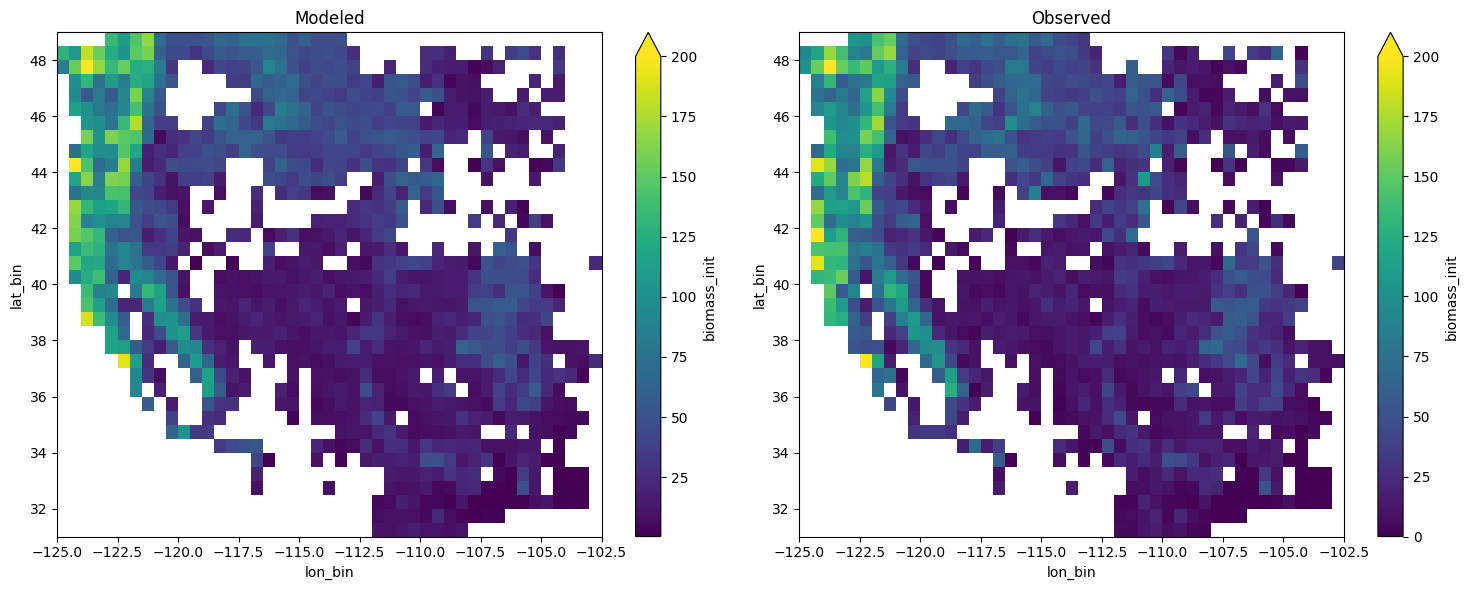

In [8]:
# Gridded maps: initial biomass
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ds_binned_modeled_init["biomass_init"].plot(vmax=200)
plt.title("Modeled")
plt.subplot(1, 2, 2)
ds_binned_obs_init["biomass_init"].plot(vmax=200)
plt.title("Observed")
plt.tight_layout()
plt.show()

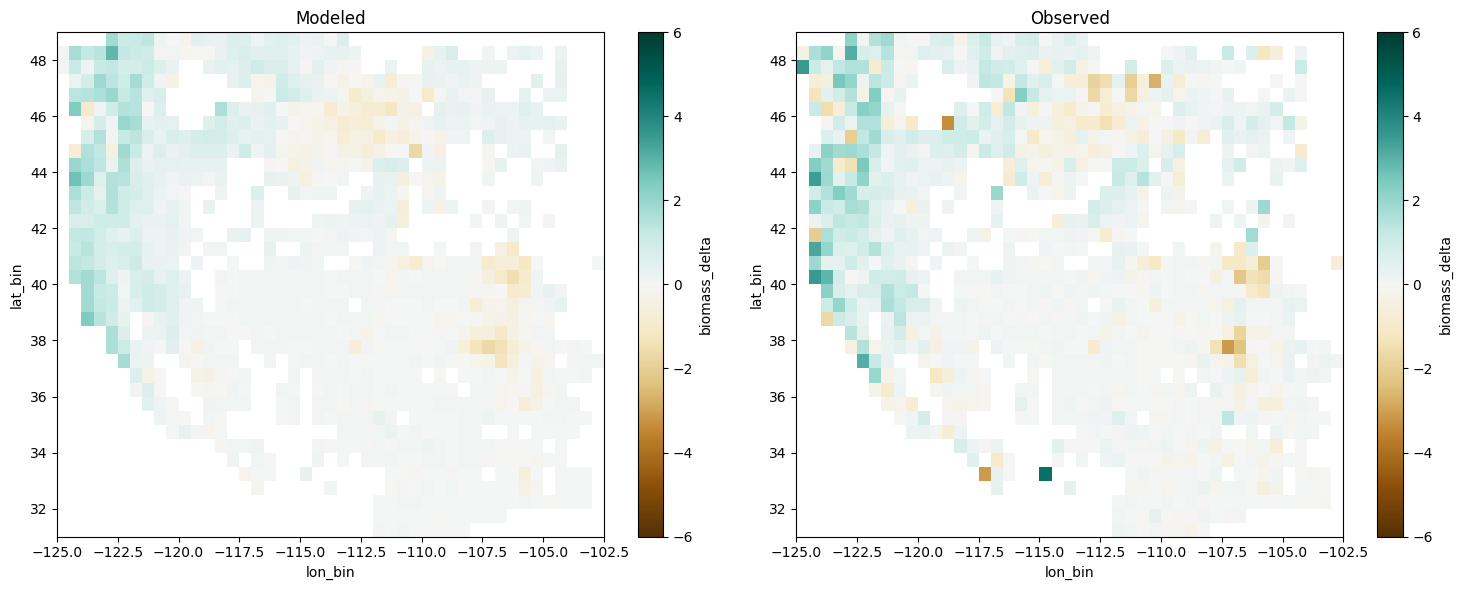

In [9]:
# Gridded maps: undisturbed delta biomass
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ds_binned_modeled_undisturbed["biomass_delta"].plot(vmax=6, cmap=plt.cm.BrBG)
plt.title("Modeled")
plt.subplot(1, 2, 2)
ds_binned_obs_undisturbed["biomass_delta"].plot(vmax=6, cmap=plt.cm.BrBG)
plt.title("Observed")
plt.tight_layout()
plt.show()

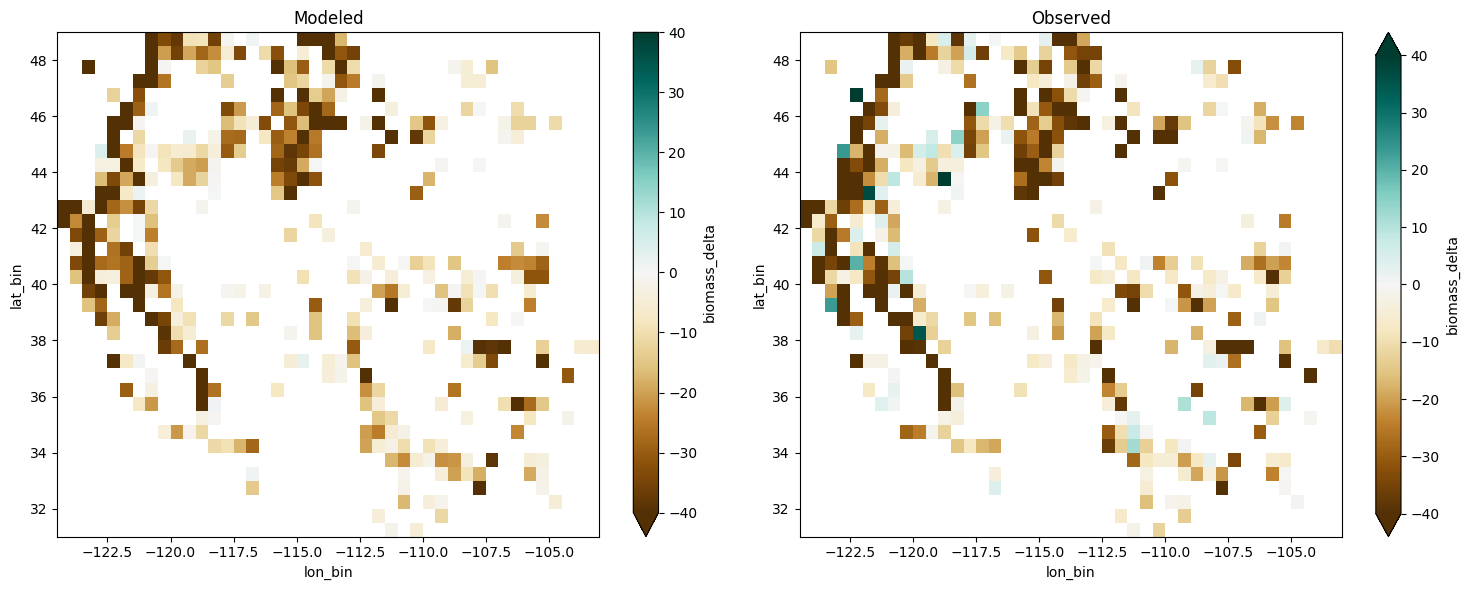

In [10]:
# Gridded maps: burned delta biomass
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
ds_binned_modeled_burned["biomass_delta"].plot(vmax=40, cmap=plt.cm.BrBG)
plt.title("Modeled")
plt.subplot(1, 2, 2)
ds_binned_obs_burned["biomass_delta"].plot(vmax=40, cmap=plt.cm.BrBG)
plt.title("Observed")
plt.tight_layout()
plt.show()

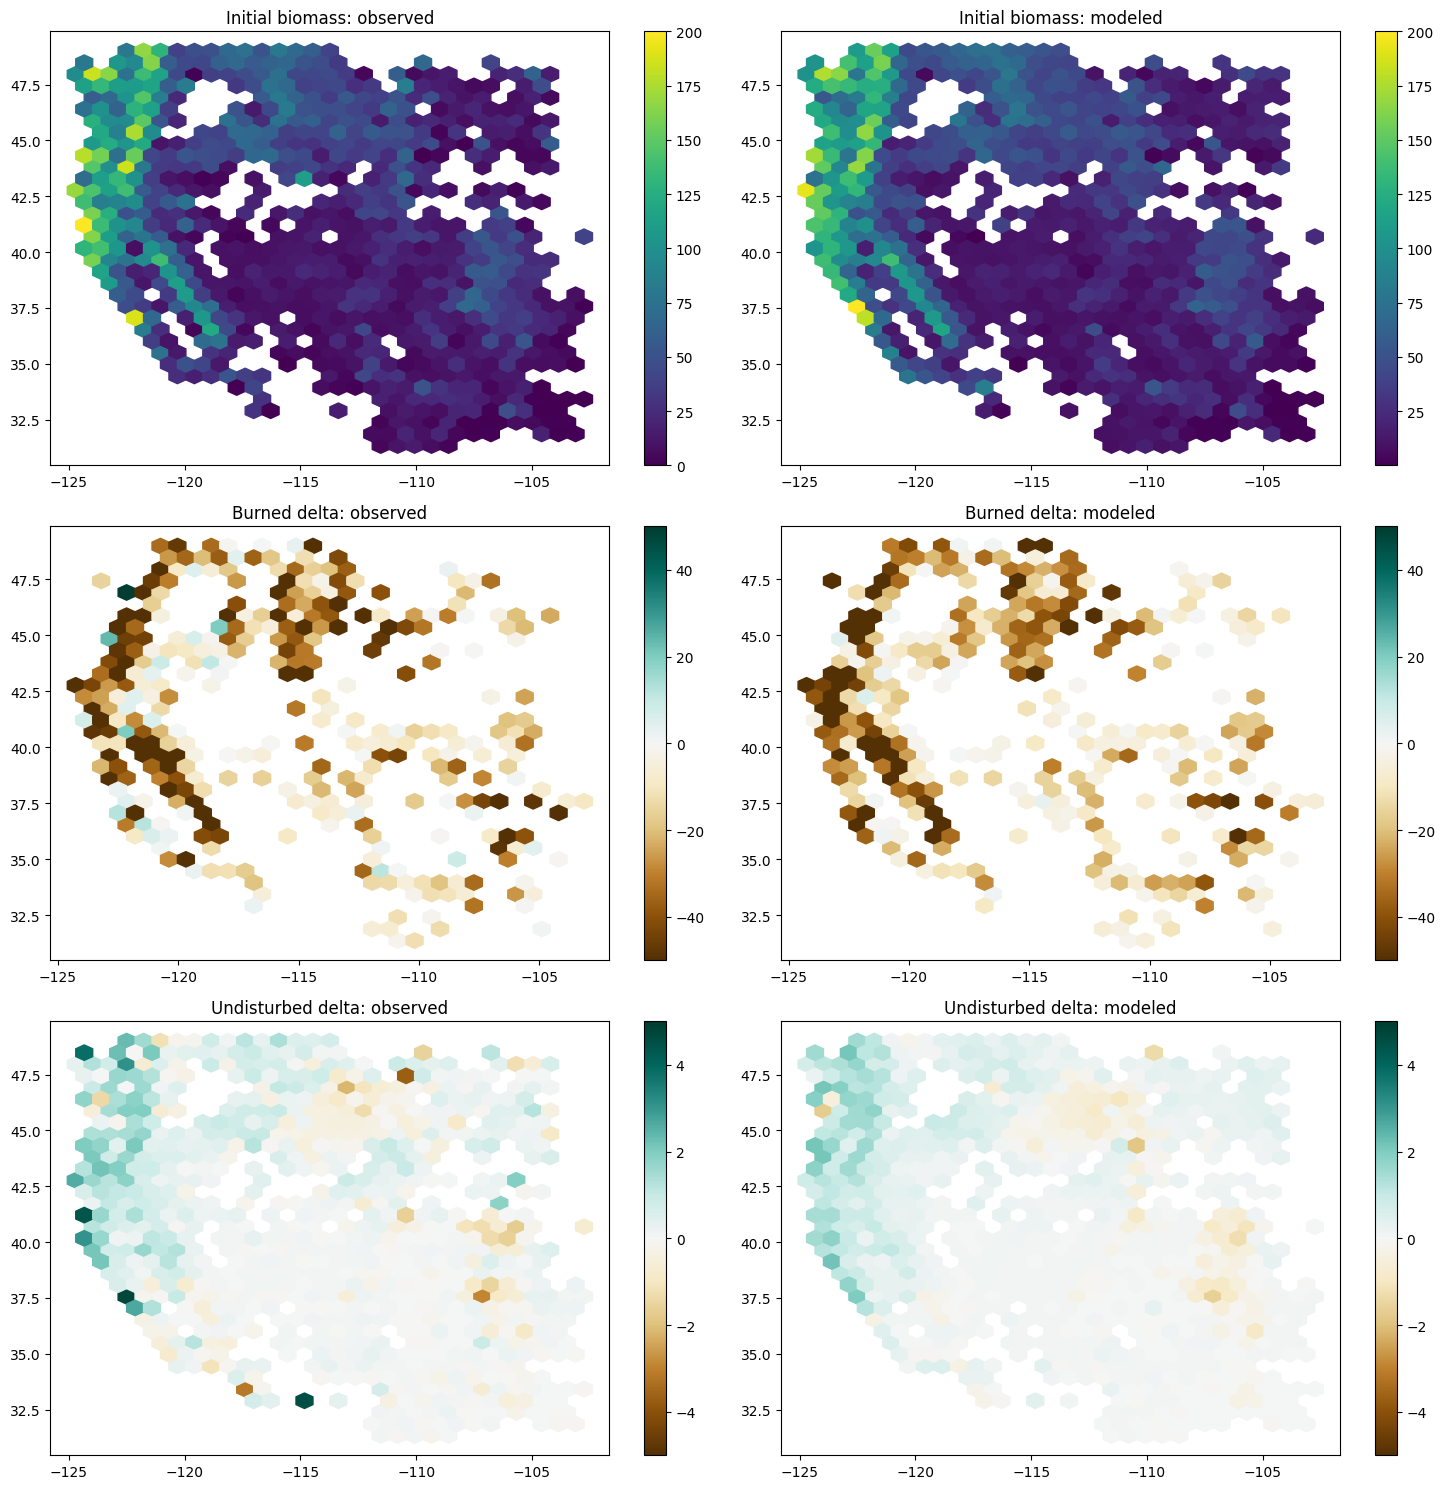

In [11]:
# Hexbin spatial maps
plt.figure(figsize=(15, 15))
plt.subplot(3, 2, 1)
plt.hexbin(x=lon_init, y=lat_init, C=y_test_init, vmax=200, gridsize=30)
plt.colorbar()
plt.title("Initial biomass: observed")
plt.subplot(3, 2, 2)
plt.hexbin(x=lon_init, y=lat_init, C=y_pred_init_test, vmax=200, gridsize=30)
plt.colorbar()
plt.title("Initial biomass: modeled")
plt.subplot(3, 2, 3)
plt.hexbin(
    x=lon_burned, y=lat_burned, C=y_test_burned, cmap=plt.cm.BrBG, vmax=50, vmin=-50, gridsize=30
)
plt.colorbar()
plt.title("Burned delta: observed")
plt.subplot(3, 2, 4)
plt.hexbin(
    x=lon_burned,
    y=lat_burned,
    C=y_pred_burned_test,
    cmap=plt.cm.BrBG,
    vmax=50,
    vmin=-50,
    gridsize=30,
)
plt.colorbar()
plt.title("Burned delta: modeled")
plt.subplot(3, 2, 5)
plt.hexbin(
    x=lon_undisturbed,
    y=lat_undisturbed,
    C=y_test_undisturbed,
    cmap=plt.cm.BrBG,
    vmax=5,
    vmin=-5,
    gridsize=30,
)
plt.colorbar()
plt.title("Undisturbed delta: observed")
plt.subplot(3, 2, 6)
plt.hexbin(
    x=lon_undisturbed,
    y=lat_undisturbed,
    C=y_pred_undisturbed_test,
    cmap=plt.cm.BrBG,
    vmax=5,
    vmin=-5,
    gridsize=30,
)
plt.colorbar()
plt.title("Undisturbed delta: modeled")
plt.tight_layout()
plt.show()